In [1]:
# ==============================================================================
# CELDA 1: IMPORTACIÓN DE LIBRERÍAS
# ==============================================================================
# Librerías necesarias para el modelo de árbol de decisión

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Modelo de árbol de decisión
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# Métricas de evaluación
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [2]:
# ==============================================================================
# CELDA 2: CARGA Y EXPLORACIÓN DEL DATASET
# ==============================================================================
# Dataset: Adult Census Income
# Objetivo: Predecir si una persona gana más de 50K al año

print("="*80)
print("CARGA Y EXPLORACIÓN DEL DATASET - ADULT CENSUS INCOME")
print("="*80)

# ----- 1. CARGAR DATASET -----
print("\n📂 Paso 1: Cargando dataset desde Hugging Face...")

# Cargar datos usando pandas desde Hugging Face
df = pd.read_csv("hf://datasets/scikit-learn/adult-census-income/adult.csv")

print(f"✅ Dataset cargado exitosamente")
print(f"   Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")

# ----- 2. PRIMERAS FILAS -----
print(f"\n📋 Primeras 10 filas del dataset:")
print(df.head(10))

# ----- 3. INFORMACIÓN DEL DATASET -----
print(f"\n📊 Información del dataset:")
print(df.info())

# ----- 4. ESTADÍSTICAS DESCRIPTIVAS -----
print(f"\n📈 Estadísticas descriptivas (variables numéricas):")
print(df.describe())

# ----- 5. VALORES NULOS -----
print(f"\n🔍 Valores nulos por columna:")
print(df.isnull().sum())

# ----- 6. DISTRIBUCIÓN DE LA VARIABLE OBJETIVO -----
print(f"\n🎯 Distribución de la variable objetivo (income):")
print(df['income'].value_counts())
print(f"\nProporción:")
print(df['income'].value_counts(normalize=True).round(4))

# ----- 7. TIPOS DE DATOS -----
print(f"\n📝 Tipos de datos:")
print(df.dtypes)

# Identificar columnas numéricas y categóricas
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n✓ Columnas numéricas ({len(numeric_cols)}): {numeric_cols}")
print(f"✓ Columnas categóricas ({len(categorical_cols)}): {categorical_cols}")

print("\n" + "="*80)

CARGA Y EXPLORACIÓN DEL DATASET - ADULT CENSUS INCOME

📂 Paso 1: Cargando dataset desde Hugging Face...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


✅ Dataset cargado exitosamente
   Dimensiones: 32,561 filas × 15 columnas

📋 Primeras 10 filas del dataset:
   age    workclass  fnlwgt     education  education.num marital.status  \
0   90            ?   77053       HS-grad              9        Widowed   
1   82      Private  132870       HS-grad              9        Widowed   
2   66            ?  186061  Some-college             10        Widowed   
3   54      Private  140359       7th-8th              4       Divorced   
4   41      Private  264663  Some-college             10      Separated   
5   34      Private  216864       HS-grad              9       Divorced   
6   38      Private  150601          10th              6      Separated   
7   74    State-gov   88638     Doctorate             16  Never-married   
8   68  Federal-gov  422013       HS-grad              9       Divorced   
9   41      Private   70037  Some-college             10  Never-married   

          occupation    relationship   race     sex  capital.gain 

In [3]:
# ==============================================================================
# CELDA 3: PREPROCESAMIENTO DE DATOS
# ==============================================================================
# Preparar los datos para el árbol de decisión:
# - Codificar variables categóricas
# - Separar features (X) y target (y)
# - Dividir en conjunto de entrenamiento y prueba

print("="*80)
print("PREPROCESAMIENTO DE DATOS")
print("="*80)

# ----- 1. HACER COPIA DEL DATASET -----
print(f"\n🔧 Paso 1: Creando copia del dataset...")
df_processed = df.copy()
print(f"✅ Copia creada")

# ----- 2. CODIFICAR VARIABLE OBJETIVO -----
print(f"\n🔧 Paso 2: Codificando variable objetivo (income)...")

# Convertir la variable objetivo a valores binarios
# <=50K → 0, >50K → 1
le_target = LabelEncoder()
df_processed['income_encoded'] = le_target.fit_transform(df_processed['income'])

print(f"✅ Variable objetivo codificada:")
print(f"   {le_target.classes_[0]} → 0")
print(f"   {le_target.classes_[1]} → 1")

# ----- 3. CODIFICAR VARIABLES CATEGÓRICAS -----
print(f"\n🔧 Paso 3: Codificando variables categóricas...")

# Crear diccionario para guardar los encoders
label_encoders = {}

# Identificar columnas categóricas (excluyendo la variable objetivo original)
categorical_features = [col for col in categorical_cols if col != 'income']

# Codificar cada columna categórica
for col in categorical_features:
    le = LabelEncoder()
    df_processed[col + '_encoded'] = le.fit_transform(df_processed[col])
    label_encoders[col] = le

    # Mostrar mapeo para las primeras 5 categorías
    unique_vals = df[col].unique()[:5]
    encoded_vals = le.transform(unique_vals)
    print(f"   ✓ {col}: {list(zip(unique_vals, encoded_vals))}")

print(f"✅ {len(categorical_features)} variables categóricas codificadas")

# ----- 4. SELECCIONAR FEATURES Y TARGET -----
print(f"\n🔧 Paso 4: Seleccionando features (X) y target (y)...")

# Features: Todas las columnas numéricas + categóricas codificadas
# Excluir las columnas categóricas originales y la variable objetivo original
features_numeric = numeric_cols  # Variables numéricas originales
features_encoded = [col + '_encoded' for col in categorical_features]  # Categóricas codificadas

feature_columns = features_numeric + features_encoded

# Crear matriz de features (X) y vector objetivo (y)
X = df_processed[feature_columns]
y = df_processed['income_encoded']

print(f"✅ Features y target seleccionados:")
print(f"   X (Features): {X.shape[0]:,} filas × {X.shape[1]} columnas")
print(f"   y (Target): {y.shape[0]:,} valores")
print(f"\n   Features utilizadas: {feature_columns}")

# ----- 5. DIVIDIR EN TRAIN Y TEST -----
print(f"\n🔧 Paso 5: Dividiendo dataset en entrenamiento y prueba...")

# División 80% entrenamiento, 20% prueba
# stratify=y asegura que ambos conjuntos tengan la misma proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% para prueba
    random_state=42,    # Semilla para reproducibilidad
    stratify=y          # Mantener proporción de clases
)

print(f"✅ Dataset dividido:")
print(f"   Entrenamiento: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Prueba:        {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verificar distribución de clases
print(f"\n   Distribución de clases en entrenamiento:")
print(f"   {pd.Series(y_train).value_counts(normalize=True).round(4)}")
print(f"\n   Distribución de clases en prueba:")
print(f"   {pd.Series(y_test).value_counts(normalize=True).round(4)}")

print("\n" + "="*80)
print("✅ PREPROCESAMIENTO COMPLETADO")
print("="*80)

PREPROCESAMIENTO DE DATOS

🔧 Paso 1: Creando copia del dataset...
✅ Copia creada

🔧 Paso 2: Codificando variable objetivo (income)...
✅ Variable objetivo codificada:
   <=50K → 0
   >50K → 1

🔧 Paso 3: Codificando variables categóricas...
   ✓ workclass: [('?', np.int64(0)), ('Private', np.int64(4)), ('State-gov', np.int64(7)), ('Federal-gov', np.int64(1)), ('Self-emp-not-inc', np.int64(6))]
   ✓ education: [('HS-grad', np.int64(11)), ('Some-college', np.int64(15)), ('7th-8th', np.int64(5)), ('10th', np.int64(0)), ('Doctorate', np.int64(10))]
   ✓ marital.status: [('Widowed', np.int64(6)), ('Divorced', np.int64(0)), ('Separated', np.int64(5)), ('Never-married', np.int64(4)), ('Married-civ-spouse', np.int64(2))]
   ✓ occupation: [('?', np.int64(0)), ('Exec-managerial', np.int64(4)), ('Machine-op-inspct', np.int64(7)), ('Prof-specialty', np.int64(10)), ('Other-service', np.int64(8))]
   ✓ relationship: [('Not-in-family', np.int64(1)), ('Unmarried', np.int64(4)), ('Own-child', np.int64(3)

In [4]:
# ==============================================================================
# CELDA 4: ENTRENAR ÁRBOL DE DECISIÓN
# ==============================================================================
# Crear y entrenar el modelo de árbol de decisión

print("="*80)
print("ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN")
print("="*80)

# ----- 1. CREAR EL MODELO -----
print(f"\n🌳 Paso 1: Creando modelo de árbol de decisión...")

# Crear el clasificador con parámetros configurados
tree_model = DecisionTreeClassifier(
    criterion='gini',        # Criterio de división: 'gini' o 'entropy'
    max_depth=10,            # Profundidad máxima del árbol (evita overfitting)
    min_samples_split=50,    # Mínimo de muestras para dividir un nodo
    min_samples_leaf=20,     # Mínimo de muestras en cada hoja
    random_state=42          # Semilla para reproducibilidad
)

print(f"✅ Modelo creado con parámetros:")
print(f"   • Criterio: {tree_model.criterion}")
print(f"   • Profundidad máxima: {tree_model.max_depth}")
print(f"   • Min muestras para dividir: {tree_model.min_samples_split}")
print(f"   • Min muestras por hoja: {tree_model.min_samples_leaf}")

# ----- 2. ENTRENAR EL MODELO -----
print(f"\n🏋️ Paso 2: Entrenando el modelo...")

# Entrenar el árbol con los datos de entrenamiento
tree_model.fit(X_train, y_train)

print(f"✅ Modelo entrenado exitosamente")

# ----- 3. INFORMACIÓN DEL ÁRBOL ENTRENADO -----
print(f"\n📊 Información del árbol entrenado:")
print(f"   • Número de nodos: {tree_model.tree_.node_count}")
print(f"   • Número de hojas: {tree_model.get_n_leaves()}")
print(f"   • Profundidad real del árbol: {tree_model.get_depth()}")

# ----- 4. HACER PREDICCIONES -----
print(f"\n🔮 Paso 3: Realizando predicciones...")

# Predicciones en conjunto de entrenamiento
y_train_pred = tree_model.predict(X_train)

# Predicciones en conjunto de prueba
y_test_pred = tree_model.predict(X_test)

print(f"✅ Predicciones realizadas:")
print(f"   • Predicciones en entrenamiento: {len(y_train_pred):,}")
print(f"   • Predicciones en prueba: {len(y_test_pred):,}")

# Mostrar ejemplo de predicciones
print(f"\n📋 Ejemplo de predicciones (primeras 10 muestras de test):")
comparison_df = pd.DataFrame({
    'Real': y_test[:10].values,
    'Predicho': y_test_pred[:10]
})
comparison_df['Real_Label'] = comparison_df['Real'].map({0: le_target.classes_[0], 1: le_target.classes_[1]})
comparison_df['Predicho_Label'] = comparison_df['Predicho'].map({0: le_target.classes_[0], 1: le_target.classes_[1]})
print(comparison_df)

print("\n" + "="*80)
print("✅ ENTRENAMIENTO COMPLETADO")
print("="*80)

ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

🌳 Paso 1: Creando modelo de árbol de decisión...
✅ Modelo creado con parámetros:
   • Criterio: gini
   • Profundidad máxima: 10
   • Min muestras para dividir: 50
   • Min muestras por hoja: 20

🏋️ Paso 2: Entrenando el modelo...
✅ Modelo entrenado exitosamente

📊 Información del árbol entrenado:
   • Número de nodos: 341
   • Número de hojas: 171
   • Profundidad real del árbol: 10

🔮 Paso 3: Realizando predicciones...
✅ Predicciones realizadas:
   • Predicciones en entrenamiento: 26,048
   • Predicciones en prueba: 6,513

📋 Ejemplo de predicciones (primeras 10 muestras de test):
   Real  Predicho Real_Label Predicho_Label
0     0         0      <=50K          <=50K
1     0         0      <=50K          <=50K
2     1         1       >50K           >50K
3     1         0       >50K          <=50K
4     0         0      <=50K          <=50K
5     0         0      <=50K          <=50K
6     0         0      <=50K          <=50K
7     0         0     

In [5]:
# ==============================================================================
# CELDA 5: MÉTRICAS DE EVALUACIÓN
# ==============================================================================
# Calcular todas las métricas de clasificación para evaluar el modelo

print("="*80)
print("MÉTRICAS DE EVALUACIÓN DEL MODELO")
print("="*80)

# ----- 1. MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO -----
print(f"\n📊 MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO:")
print("-" * 80)

train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

print(f"   • Accuracy:  {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"   • Precision: {train_precision:.4f}")
print(f"   • Recall:    {train_recall:.4f}")
print(f"   • F1-Score:  {train_f1:.4f}")

# ----- 2. MÉTRICAS EN CONJUNTO DE PRUEBA -----
print(f"\n📊 MÉTRICAS EN CONJUNTO DE PRUEBA:")
print("-" * 80)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f"   • Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   • Precision: {test_precision:.4f}")
print(f"   • Recall:    {test_recall:.4f}")
print(f"   • F1-Score:  {test_f1:.4f}")

# ----- 3. INTERPRETACIÓN DE MÉTRICAS -----
print(f"\n💡 INTERPRETACIÓN:")
print("-" * 80)

print(f"\n   🎯 ACCURACY ({test_accuracy*100:.1f}%):")
print(f"      → De cada 100 predicciones, {test_accuracy*100:.0f} son correctas")

print(f"\n   🎯 PRECISION ({test_precision:.3f}):")
print(f"      → De las personas que el modelo predice que ganan >50K,")
print(f"        {test_precision*100:.0f}% realmente lo hacen")

print(f"\n   🎯 RECALL ({test_recall:.3f}):")
print(f"      → De todas las personas que ganan >50K,")
print(f"        el modelo detecta {test_recall*100:.0f}%")

print(f"\n   🎯 F1-SCORE ({test_f1:.3f}):")
print(f"      → Balance entre precision y recall (0=malo, 1=perfecto)")

# ----- 4. COMPARACIÓN TRAIN VS TEST -----
print(f"\n📊 COMPARACIÓN ENTRENAMIENTO vs PRUEBA:")
print("-" * 80)

comparison_table = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Entrenamiento': [train_accuracy, train_precision, train_recall, train_f1],
    'Prueba': [test_accuracy, test_precision, test_recall, test_f1],
    'Diferencia': [
        train_accuracy - test_accuracy,
        train_precision - test_precision,
        train_recall - test_recall,
        train_f1 - test_f1
    ]
})
comparison_table['Diferencia %'] = (comparison_table['Diferencia'] * 100).round(2)

print(comparison_table.to_string(index=False))

# Detectar overfitting
overfitting_threshold = 0.05  # 5% de diferencia
if (train_accuracy - test_accuracy) > overfitting_threshold:
    print(f"\n⚠️ ADVERTENCIA: Posible overfitting detectado")
    print(f"   La diferencia entre train y test es {(train_accuracy - test_accuracy)*100:.1f}%")
else:
    print(f"\n✅ El modelo generaliza bien (diferencia train-test < 5%)")

# ----- 5. REPORTE DE CLASIFICACIÓN COMPLETO -----
print(f"\n📋 REPORTE DE CLASIFICACIÓN DETALLADO (CONJUNTO DE PRUEBA):")
print("-" * 80)
print(classification_report(
    y_test,
    y_test_pred,
    target_names=[le_target.classes_[0], le_target.classes_[1]],
    digits=4
))

# ----- 6. MATRIZ DE CONFUSIÓN -----
print(f"\n📊 MATRIZ DE CONFUSIÓN (CONJUNTO DE PRUEBA):")
print("-" * 80)

cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\n                    Predicho")
print(f"                 <=50K    >50K")
print(f"Real   <=50K    {tn:6d}   {fp:6d}")
print(f"       >50K     {fn:6d}   {tp:6d}")

print(f"\nDesglose:")
print(f"   • True Negatives (TN):  {tn:,} - Correctamente clasificados como <=50K ✅")
print(f"   • True Positives (TP):  {tp:,} - Correctamente clasificados como >50K ✅")
print(f"   • False Positives (FP): {fp:,} - Incorrectamente clasificados como >50K ❌")
print(f"   • False Negatives (FN): {fn:,} - Incorrectamente clasificados como <=50K ❌")

print("\n" + "="*80)

MÉTRICAS DE EVALUACIÓN DEL MODELO

📊 MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO:
--------------------------------------------------------------------------------
   • Accuracy:  0.8635 (86.35%)
   • Precision: 0.7528
   • Recall:    0.6448
   • F1-Score:  0.6947

📊 MÉTRICAS EN CONJUNTO DE PRUEBA:
--------------------------------------------------------------------------------
   • Accuracy:  0.8524 (85.24%)
   • Precision: 0.7257
   • Recall:    0.6224
   • F1-Score:  0.6701

💡 INTERPRETACIÓN:
--------------------------------------------------------------------------------

   🎯 ACCURACY (85.2%):
      → De cada 100 predicciones, 85 son correctas

   🎯 PRECISION (0.726):
      → De las personas que el modelo predice que ganan >50K,
        73% realmente lo hacen

   🎯 RECALL (0.622):
      → De todas las personas que ganan >50K,
        el modelo detecta 62%

   🎯 F1-SCORE (0.670):
      → Balance entre precision y recall (0=malo, 1=perfecto)

📊 COMPARACIÓN ENTRENAMIENTO vs PRUEBA:
--------

VISUALIZACIÓN DEL MODELO

📊 Generando visualización de la Matriz de Confusión...


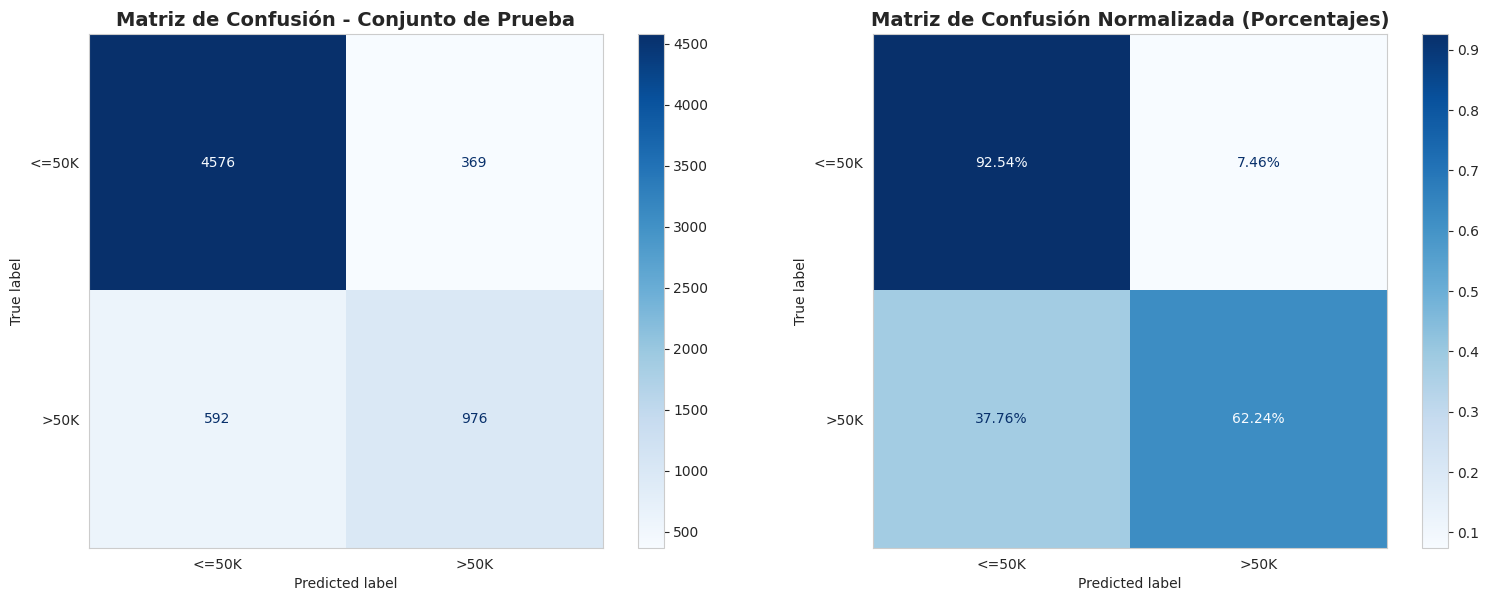

✅ Matriz de confusión visualizada

🌳 Generando visualización del Árbol de Decisión...
   Nota: El árbol tiene 341 nodos
   Se mostrará una versión simplificada (profundidad máxima = 3)


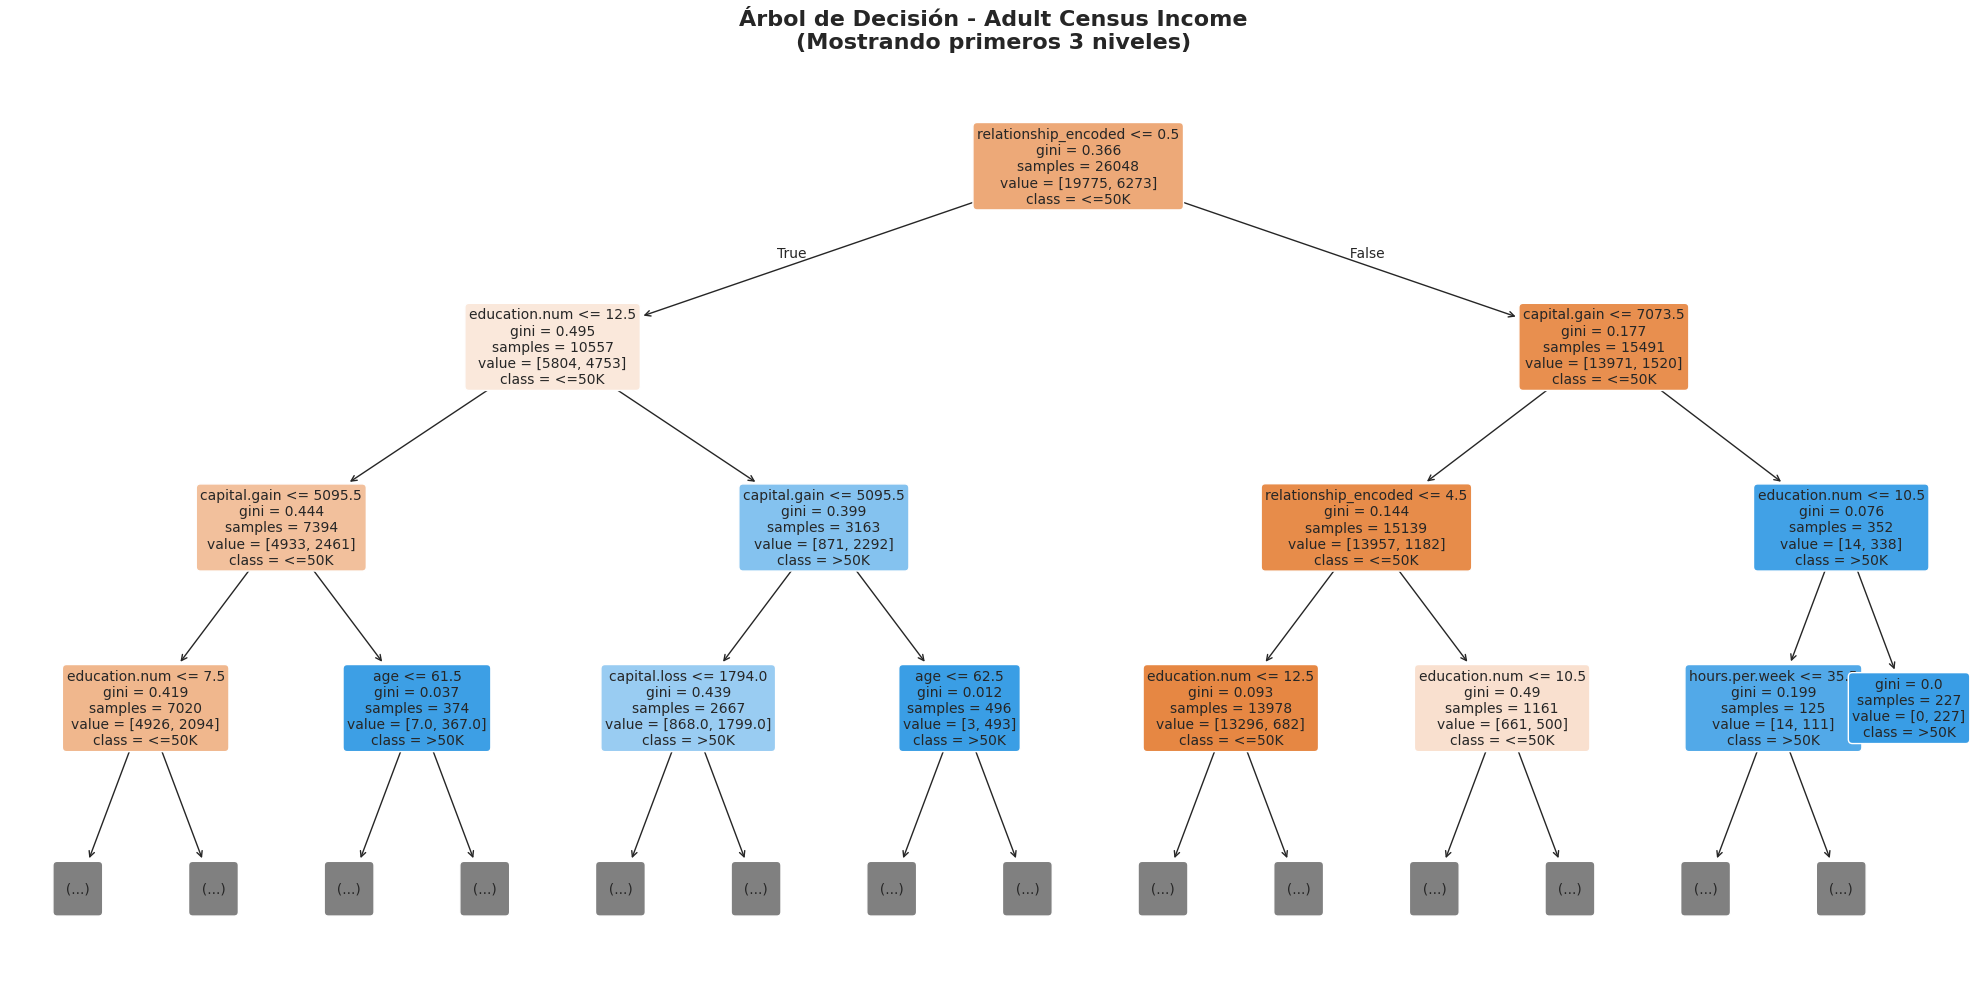

✅ Árbol de decisión visualizado

📊 Generando gráfico de comparación de métricas...


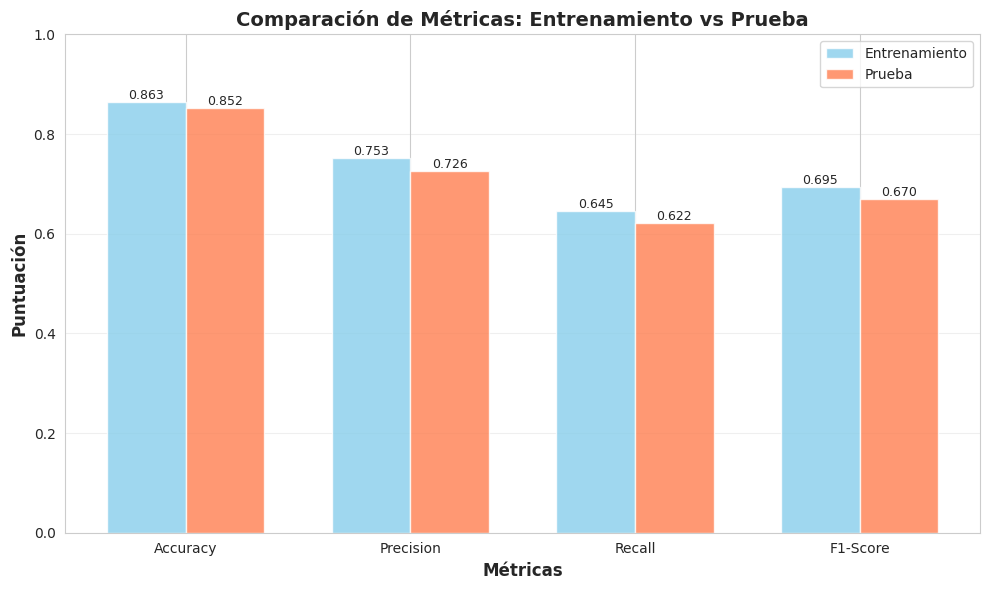

✅ Gráfico de métricas generado

✅ VISUALIZACIONES COMPLETADAS


In [6]:
# ==============================================================================
# CELDA 6: VISUALIZACIÓN DEL ÁRBOL Y MATRIZ DE CONFUSIÓN
# ==============================================================================
# Crear visualizaciones del árbol de decisión y matriz de confusión

print("="*80)
print("VISUALIZACIÓN DEL MODELO")
print("="*80)

# ----- 1. VISUALIZACIÓN DE LA MATRIZ DE CONFUSIÓN -----
print(f"\n📊 Generando visualización de la Matriz de Confusión...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Matriz de confusión
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[le_target.classes_[0], le_target.classes_[1]]
)
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Matriz de Confusión - Conjunto de Prueba', fontsize=14, fontweight='bold')
axes[0].grid(False)

# Subplot 2: Matriz de confusión normalizada (porcentajes)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=[le_target.classes_[0], le_target.classes_[1]]
)
disp_norm.plot(ax=axes[1], cmap='Blues', values_format='.2%')
axes[1].set_title('Matriz de Confusión Normalizada (Porcentajes)', fontsize=14, fontweight='bold')
axes[1].grid(False)

plt.tight_layout()
plt.show()

print("✅ Matriz de confusión visualizada")

# ----- 2. VISUALIZACIÓN DEL ÁRBOL DE DECISIÓN -----
print(f"\n🌳 Generando visualización del Árbol de Decisión...")
print(f"   Nota: El árbol tiene {tree_model.tree_.node_count} nodos")
print(f"   Se mostrará una versión simplificada (profundidad máxima = 3)")

# Crear figura grande para el árbol
plt.figure(figsize=(20, 10))

# Visualizar árbol (limitado a profundidad 3 para legibilidad)
plot_tree(
    tree_model,
    max_depth=3,                    # Limitar profundidad mostrada
    feature_names=feature_columns,  # Nombres de las features
    class_names=[le_target.classes_[0], le_target.classes_[1]],  # Nombres de clases
    filled=True,                    # Colorear nodos según clase mayoritaria
    rounded=True,                   # Bordes redondeados
    fontsize=10                     # Tamaño de fuente
)

plt.title('Árbol de Decisión - Adult Census Income\n(Mostrando primeros 3 niveles)',
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✅ Árbol de decisión visualizado")

# ----- 3. RESUMEN VISUAL -----
print(f"\n📊 Generando gráfico de comparación de métricas...")

fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
train_scores = [train_accuracy, train_precision, train_recall, train_f1]
test_scores = [test_accuracy, test_precision, test_recall, test_f1]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, train_scores, width, label='Entrenamiento', color='skyblue', alpha=0.8)
bars2 = ax.bar(x + width/2, test_scores, width, label='Prueba', color='coral', alpha=0.8)

ax.set_xlabel('Métricas', fontsize=12, fontweight='bold')
ax.set_ylabel('Puntuación', fontsize=12, fontweight='bold')
ax.set_title('Comparación de Métricas: Entrenamiento vs Prueba', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3)

# Añadir valores encima de las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("✅ Gráfico de métricas generado")

print("\n" + "="*80)
print("✅ VISUALIZACIONES COMPLETADAS")
print("="*80)